<a href="https://colab.research.google.com/github/alaae2007/CST184/blob/main/Week_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RENEWABLE ENERGY DATASET

First 5 rows of the dataset:
   Country         Region  Population  %Renewable  CO2_Emissions
0    Nepal           Asia          30          89            0.3
1    Kenya         Africa          54          76            0.5
2   Brazil  South America         213          45            2.1
3    India           Asia        1400          24            1.9
4  Germany         Europe          83          48            9.6

COUNTRY AND RENEWABLE ENERGY PERCENTAGE
     Country  %Renewable
0      Nepal          89
1      Kenya          76
2     Brazil          45
3      India          24
4    Germany          48
5     Norway          98
6  Australia          30
7    Nigeria          17
8    Vietnam          64
9     Mexico          41

COUNTRIES WITH MORE THAN 50% RENEWABLE ENERGY
   Country  Region  Population  %Renewable  CO2_Emissions
0    Nepal    Asia          30          89            0.3
1    Kenya  Africa          54          76            0.5
5   Norway  Europe

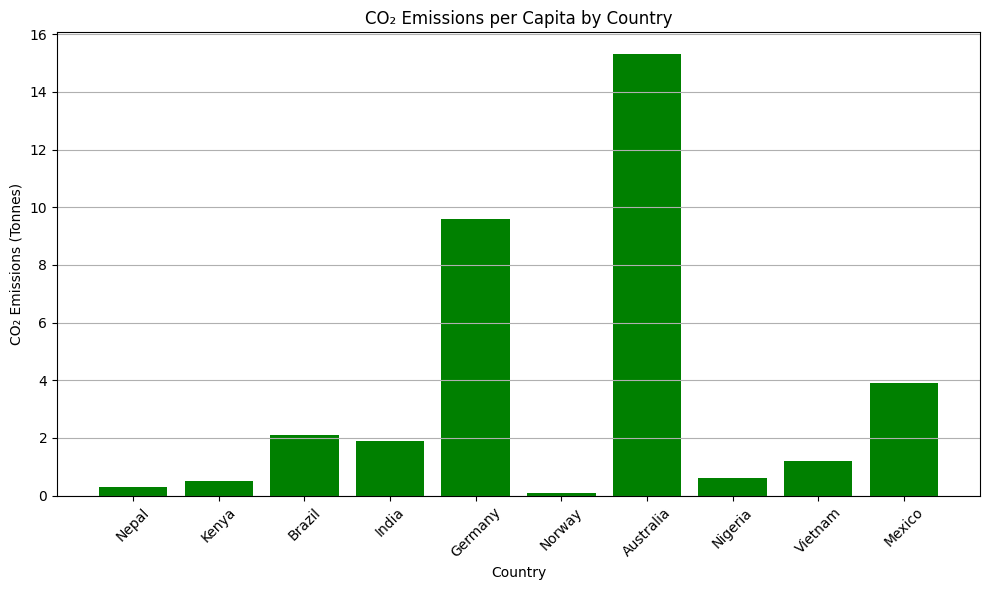

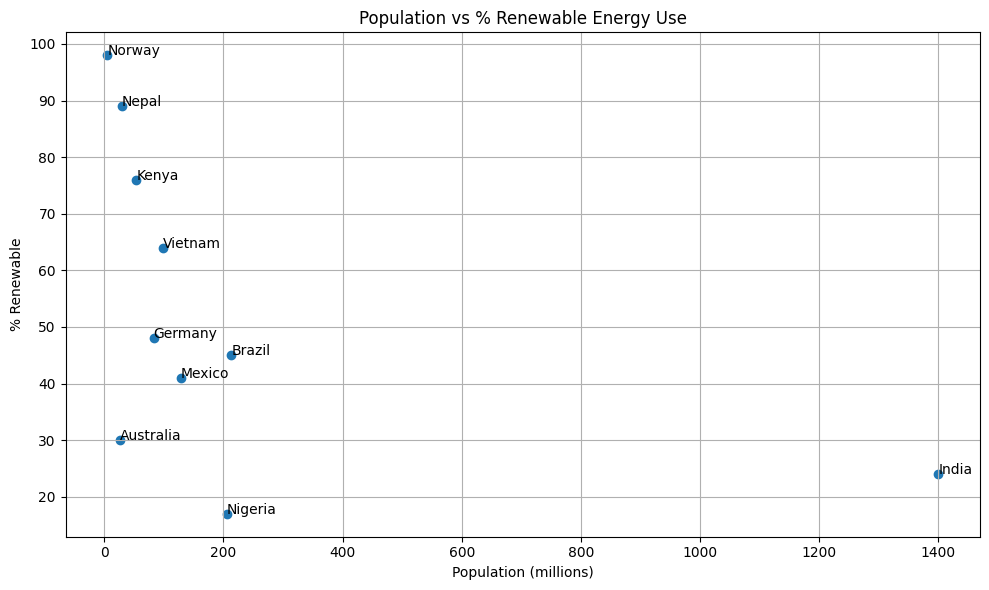


ASIAN COUNTRIES
   Country Region  Population  %Renewable  CO2_Emissions
0    Nepal   Asia          30          89            0.3
3    India   Asia        1400          24            1.9
8  Vietnam   Asia          98          64            1.2


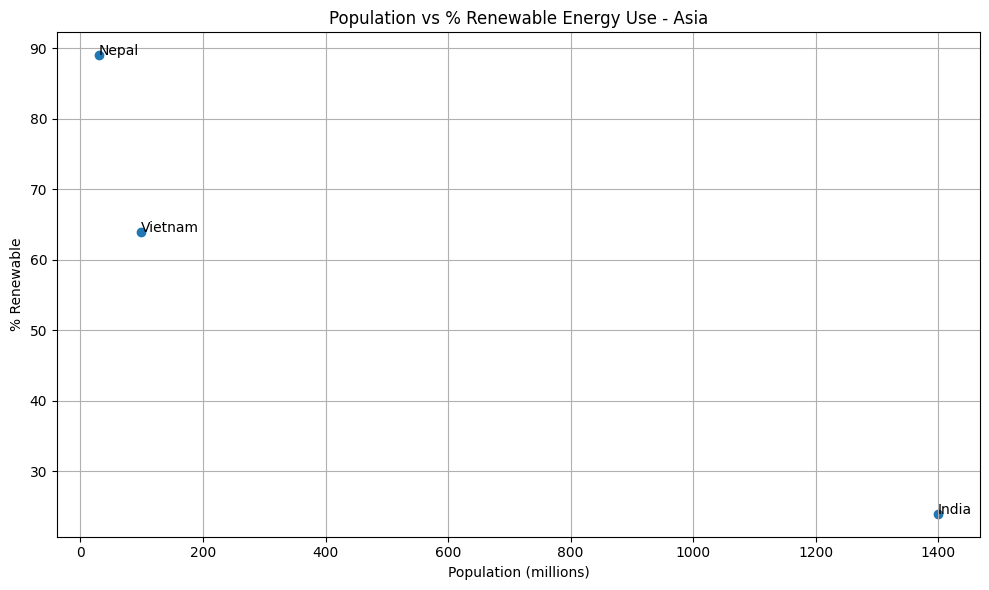


COUNTRIES WITH MORE THAN 60% RENEWABLE ENERGY
   Country  Region  Population  %Renewable  CO2_Emissions
0    Nepal    Asia          30          89            0.3
1    Kenya  Africa          54          76            0.5
5   Norway  Europe           5          98            0.1
8  Vietnam    Asia          98          64            1.2

File saved successfully as:
high_renewable_countries.csv

AVERAGE RENEWABLE ENERGY USE BY REGION
Region
Europe           73.0
Asia             59.0
Africa           46.5
South America    45.0
North America    41.0
Oceania          30.0
Name: %Renewable, dtype: float64

COUNTRY WITH HIGHEST RENEWABLE ENERGY USE
Country: Norway
Region: Europe
Renewable Energy: 98 %

POPULATION VS RENEWABLE ENERGY CORRELATION
Correlation: -0.471

REFLECTION

1. Which regions have the highest renewable energy adoption?

Europe has the highest average renewable energy adoption in this
dataset, followed by Asia. Norway has the highest individual
renewable energy percentage.

2

In [2]:

# CST184 - WEEK 1
# Renewable Energy Analysis



# STEP 1 - IMPORT LIBRARIES AND LOAD DATA


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/renewable_energy.csv")

print("=" * 70)
print("RENEWABLE ENERGY DATASET")
print("=" * 70)

print("\nFirst 5 rows of the dataset:")
print(df.head())



# TRY THIS - PRINT COUNTRY AND %RENEWABLE COLUMNS


print("\n" + "=" * 70)
print("COUNTRY AND RENEWABLE ENERGY PERCENTAGE")
print("=" * 70)

print(df[["Country", "%Renewable"]])



# STEP 2 - FILTER COUNTRIES ABOVE 50% RENEWABLE ENERGY


high_renewable = df[df["%Renewable"] > 50]

print("\n" + "=" * 70)
print("COUNTRIES WITH MORE THAN 50% RENEWABLE ENERGY")
print("=" * 70)

print(high_renewable)


# TRY THIS - CHANGE THRESHOLD TO 70%


high_renewable_70 = df[df["%Renewable"] > 70]

print("\n" + "=" * 70)
print("COUNTRIES WITH MORE THAN 70% RENEWABLE ENERGY")
print("=" * 70)

print(high_renewable_70)



# STEP 3 - CREATE A SET


high_set = set(high_renewable["Country"])

print("\n" + "=" * 70)
print("SET OF COUNTRIES WITH MORE THAN 50% RENEWABLE ENERGY")
print("=" * 70)

print("Countries:", high_set)
print("Cardinality:", len(high_set))


# STEP 4 - CREATE A DICTIONARY


emissions_dict = dict(
    zip(df["Country"], df["CO2_Emissions"])
)

print("\n" + "=" * 70)
print("CO2 EMISSIONS DICTIONARY")
print("=" * 70)

print(emissions_dict)

print("\nBrazil CO2 Emissions:")
print(emissions_dict["Brazil"])


# STEP 5 - BAR CHART OF CO2 EMISSIONS


plt.figure(figsize=(10, 6))

plt.bar(
    emissions_dict.keys(),
    emissions_dict.values(),
    color="green"
)

plt.title("CO₂ Emissions per Capita by Country")
plt.xlabel("Country")
plt.ylabel("CO₂ Emissions (Tonnes)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()


# STEP 6 - SCATTERPLOT
# POPULATION VS RENEWABLE ENERGY


plt.figure(figsize=(10, 6))

plt.scatter(
    df["Population"],
    df["%Renewable"]
)

for i in range(len(df)):
    plt.text(
        df["Population"].iloc[i],
        df["%Renewable"].iloc[i],
        df["Country"].iloc[i]
    )

plt.title("Population vs % Renewable Energy Use")
plt.xlabel("Population (millions)")
plt.ylabel("% Renewable")
plt.grid(True)
plt.tight_layout()

plt.show()



# CHALLENGE - PLOT ONLY COUNTRIES IN ASIA


asia_df = df[df["Region"] == "Asia"]

print("\n" + "=" * 70)
print("ASIAN COUNTRIES")
print("=" * 70)

print(asia_df)

plt.figure(figsize=(10, 6))

plt.scatter(
    asia_df["Population"],
    asia_df["%Renewable"]
)

for i in asia_df.index:
    plt.text(
        asia_df.loc[i, "Population"],
        asia_df.loc[i, "%Renewable"],
        asia_df.loc[i, "Country"]
    )

plt.title("Population vs % Renewable Energy Use - Asia")
plt.xlabel("Population (millions)")
plt.ylabel("% Renewable")
plt.grid(True)
plt.tight_layout()

plt.show()



# STEP 7 - SAVE FILTERED SUBSET


subset = df[df["%Renewable"] > 60]

subset.to_csv(
    "high_renewable_countries.csv",
    index=False
)

print("\n" + "=" * 70)
print("COUNTRIES WITH MORE THAN 60% RENEWABLE ENERGY")
print("=" * 70)

print(subset)

print("\nFile saved successfully as:")
print("high_renewable_countries.csv")



# EXTRA ANALYSIS FOR REFLECTION QUESTIONS


print("\n" + "=" * 70)
print("AVERAGE RENEWABLE ENERGY USE BY REGION")
print("=" * 70)

region_average = (
    df.groupby("Region")["%Renewable"]
    .mean()
    .sort_values(ascending=False)
)

print(region_average)



# FIND COUNTRY WITH HIGHEST RENEWABLE ENERGY USE


highest_country = df.loc[df["%Renewable"].idxmax()]

print("\n" + "=" * 70)
print("COUNTRY WITH HIGHEST RENEWABLE ENERGY USE")
print("=" * 70)

print("Country:", highest_country["Country"])
print("Region:", highest_country["Region"])
print("Renewable Energy:", highest_country["%Renewable"], "%")


# CHECK RELATIONSHIP BETWEEN POPULATION AND RENEWABLE USE


correlation = df["Population"].corr(df["%Renewable"])

print("\n" + "=" * 70)
print("POPULATION VS RENEWABLE ENERGY CORRELATION")
print("=" * 70)

print("Correlation:", round(correlation, 3))


# REFLECTION ANSWERS


print("\n" + "=" * 70)
print("REFLECTION")
print("=" * 70)

print("""
1. Which regions have the highest renewable energy adoption?

Europe has the highest average renewable energy adoption in this
dataset, followed by Asia. Norway has the highest individual
renewable energy percentage.

2. Is there a relationship between population size and renewable use?

The data shows a negative relationship between population size and
renewable energy use. Some countries with smaller populations have
very high renewable percentages, while some larger countries have
lower percentages. However, because the dataset only contains a small
number of countries, this relationship should not be treated as a
general conclusion.

3. How does changing the filter affect the visualisation?

Increasing the renewable energy threshold reduces the number of
countries included. For example, filtering above 70% produces fewer
results than filtering above 50%. This makes the results more focused
on countries with very high renewable energy adoption.
""")